Practical B: Molecular Descriptors
Title

To Calculate Molecular Descriptors for Natural Products Using Computational Tools — A Comprehensive Physicochemical and Structural Characterization of the COCONUT Natural Product Dataset

Object

To calculate molecular descriptors for natural products using computational tools — establishing the numerical, machine-readable characterization of chemical structure that underlies every subsequent quantitative task in this practical series (QSAR modelling, virtual screening, lead optimization, and bioactivity prediction).

Objectives
To understand what a molecular descriptor is and why converting a chemical structure into numerical form is the essential first step of any computational drug discovery workflow.
To calculate a comprehensive panel of physicochemical descriptors (molecular weight, LogP, hydrogen bond donors/acceptors, topological polar surface area, rotatable bonds, aromatic ring count) for the 2,000-compound natural product dataset.
To calculate structural fingerprint-based descriptors (Morgan fingerprints) capturing substructural composition, distinct from whole-molecule physicochemical properties.
To apply and interpret classical drug-likeness filters (Lipinski's Rule of Five, Veber's Rules) specifically in the context of natural products, and to understand why natural products frequently violate these synthetic-drug-oriented rules.
To statistically analyze and visualize the descriptor space of natural products — correlations between descriptors, distributions, and outlier identification.
To reduce descriptor dimensionality using Principal Component Analysis and visualize the natural product chemical space in two dimensions.
To build a deployment tool that calculates the complete descriptor profile for any new compound a student provides.
Expected Outcomes

Conceptual outcomes:

Explain what a molecular descriptor is and distinguish between physicochemical descriptors (whole-molecule properties) and structural fingerprints (substructural patterns).
Understand why molecular descriptors are the mandatory numerical bridge between raw chemical structure and any machine learning model.
Explain why natural products, as a class, often deviate from classical synthetic-drug-oriented rules like Lipinski's Rule of Five, and why this does not diminish their drug discovery value.

Technical outcomes:

Independently calculate a full physicochemical descriptor panel for any molecule using RDKit.
Generate and interpret Morgan fingerprints as a complementary descriptor type.
Apply Lipinski and Veber drug-likeness filters and interpret pass/fail results in a natural-product-specific context.
Use correlation analysis to identify redundant descriptors.
Apply PCA to visualize high-dimensional descriptor space in two interpretable dimensions.

Practical outcomes:

Produce a complete, machine-learning-ready descriptor table for the entire natural product dataset — the direct numerical input required by every subsequent practical (QSAR, virtual screening, lead optimization, bioactivity prediction) in this series.
Independently characterize any new natural product or synthetic compound of interest using the deployment tool.

In [1]:
# Block 1: Load natural product dataset and calculate physicochemical descriptors

!pip install rdkit pandas numpy matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("MOLECULAR DESCRIPTOR CALCULATION FOR NATURAL PRODUCTS")
print("="*60)

url = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/coconut_natural_products_2000.csv"

df = pd.read_csv(url)

print(f"Loaded: {df.shape[0]} natural products, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

print(f"\n{'='*60}")
print("CALCULATING PHYSICOCHEMICAL DESCRIPTORS")
print(f"{'='*60}")
print("A molecular descriptor is any numerical value that")
print("characterizes a property of a chemical structure - size,")
print("shape, polarity, or electronic character - converting a")
print("SMILES string into a form machine learning models can use.")
print("="*60)

def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Crippen.MolLogP(mol),
        'HBD': Lipinski.NumHDonors(mol),
        'HBA': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'RotatableBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': Descriptors.NumAromaticRings(mol),
        'HeavyAtoms': mol.GetNumHeavyAtoms(),
        'RingCount': Descriptors.RingCount(mol),
        'FractionCSP3': Descriptors.FractionCSP3(mol),
        'NumHeteroatoms': Descriptors.NumHeteroatoms(mol),
        'MolarRefractivity': Crippen.MolMR(mol)
    }

print(f"\nCalculating 12 physicochemical descriptors for all "
      f"{len(df)} compounds...")

descriptor_results = []
failed = []

for idx, row in df.iterrows():
    desc = calculate_descriptors(row['SMILES'])
    if desc is None:
        failed.append(row['COCONUT_ID'])
        desc = {k: None for k in [
            'MolWt', 'LogP', 'HBD', 'HBA', 'TPSA',
            'RotatableBonds', 'AromaticRings', 'HeavyAtoms',
            'RingCount', 'FractionCSP3', 'NumHeteroatoms',
            'MolarRefractivity'
        ]}
    descriptor_results.append(desc)

df_desc = pd.DataFrame(descriptor_results)
df = pd.concat([df.reset_index(drop=True), df_desc], axis=1)

print(f"Descriptor calculation complete")
print(f"Failed calculations: {len(failed)}")

if failed:
    df = df.dropna(subset=['MolWt']).reset_index(drop=True)
    print(f"Compounds after removing failures: {len(df)}")

print(f"\nDescriptor summary statistics:")
desc_cols = ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA',
             'RotatableBonds', 'AromaticRings', 'HeavyAtoms',
             'RingCount', 'FractionCSP3', 'NumHeteroatoms',
             'MolarRefractivity']
print(df[desc_cols].describe().round(2).to_string())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 21.4 MB/s eta 0:00:00
MOLECULAR DESCRIPTOR CALCULATION FOR NATURAL PRODUCTS
Loaded: 2000 natural products, 6 columns
Columns: ['COCONUT_ID', 'SMILES', 'Molecular_Weight', 'NP_Likeness', 'QED_Score', 'Synthetic_Accessibility']

CALCULATING PHYSICOCHEMICAL DESCRIPTORS
A molecular descriptor is any numerical value that
characterizes a property of a chemical structure - size,
shape, polarity, or electronic character - converting a
SMILES string into a form machine learning models can use.

Calculating 12 physicochemical descriptors for all 2000 compounds...
Descriptor calculation complete
Failed calculations: 0

Descriptor summary statistics:
         MolWt     LogP      HBD      HBA     TPSA  RotatableBonds  AromaticRings  HeavyAtoms  RingCount  FractionCSP3  NumHeteroatoms  MolarRefractivity
count  2000.00  2000.00  2000.00  2000.00  2000.00         2000.00        2000.00     2000.00    2000.00       2000.00         2000.00        

Meaning of Block 1:

Purpose: Load the curated natural product dataset from GitHub and calculate a comprehensive panel of twelve physicochemical descriptors — the fundamental numerical characterization of chemical structure that every later practical in this series will build upon.

What data comes IN: coconut_natural_products_2000.csv from GitHub — 2,000 rows, 6 columns.

What a molecular descriptor is: A molecular descriptor is any single number that captures one measurable property of a chemical structure. Some describe size (molecular weight, heavy atom count), some describe polarity or electronic character (LogP, TPSA), some describe flexibility (rotatable bonds), and some describe shape complexity (ring count, fraction of sp3 carbons). Together, a panel of descriptors transforms an unstructured chemical drawing into a structured numerical table — the mandatory format required by any machine learning algorithm.

What happens inside — line by line:

Descriptors.MolWt(mol) — molecular weight, the most fundamental size descriptor.
Crippen.MolLogP(mol) — calculated octanol-water partition coefficient, estimating lipophilicity (how readily a molecule dissolves in fat versus water) — critical for predicting membrane permeability and oral absorption.
Lipinski.NumHDonors(mol) and Lipinski.NumHAcceptors(mol) — counts of hydrogen bond donor and acceptor groups, directly relevant to both drug-likeness assessment and, later in this series, pharmacophore-relevant binding interactions.
Descriptors.TPSA(mol) — Topological Polar Surface Area, the total surface area contributed by polar atoms, strongly correlated with a molecule's ability to cross biological membranes (including the blood-brain barrier).
Descriptors.NumRotatableBonds(mol) — counts single bonds that can freely rotate, a measure of molecular flexibility relevant to binding entropy and oral bioavailability.
Descriptors.FractionCSP3(mol) — the fraction of carbon atoms that are sp3-hybridized (tetrahedral, "3D-shaped") rather than sp2 (flat, aromatic-like) — natural products characteristically show higher FractionCSP3 than purely synthetic, flat aromatic-heavy compound libraries, making this a particularly relevant descriptor for this specific dataset.
Crippen.MolMR(mol) — Molar Refractivity, related to molecular polarizability and size, commonly used alongside LogP in classical QSAR equations.

What comes OUT: df — now enriched with 12 new physicochemical descriptor columns for every compound, forming the core numerical dataset used throughout the rest of this practical.

In [2]:
# Block 2: Calculate Morgan fingerprints and apply drug-likeness filters

from rdkit.Chem import rdFingerprintGenerator

print("="*60)
print("STRUCTURAL FINGERPRINT DESCRIPTORS")
print("="*60)
print("While physicochemical descriptors describe whole-molecule")
print("properties, Morgan fingerprints describe LOCAL substructural")
print("patterns - which specific atomic neighborhoods are present.")
print("This complementary descriptor type will be used directly")
print("in the QSAR and virtual screening practicals that follow.")
print("="*60)

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return morgan_gen.GetFingerprintAsNumPy(mol)

print(f"\nGenerating 1024-bit Morgan fingerprints (radius=2)...")
fingerprints = df['SMILES'].apply(get_fingerprint)
fp_matrix = np.stack(fingerprints.values)

print(f"Fingerprint matrix shape: {fp_matrix.shape}")
print(f"Average bits set per molecule: {fp_matrix.sum(axis=1).mean():.1f}")

np.save('/content/morgan_fingerprints.npy', fp_matrix)

print(f"\n{'='*60}")
print("DRUG-LIKENESS FILTER APPLICATION")
print(f"{'='*60}")

df['Lipinski_Pass'] = (
    (df['MolWt'] <= 500) &
    (df['LogP'] <= 5) &
    (df['HBD'] <= 5) &
    (df['HBA'] <= 10)
)

df['Veber_Pass'] = (
    (df['RotatableBonds'] <= 10) &
    (df['TPSA'] <= 140)
)

df['Both_Pass'] = df['Lipinski_Pass'] & df['Veber_Pass']

print(f"Lipinski Rule of Five - Pass: {df['Lipinski_Pass'].sum()} "
      f"({df['Lipinski_Pass'].mean()*100:.1f}%)")
print(f"Veber's Rules - Pass: {df['Veber_Pass'].sum()} "
      f"({df['Veber_Pass'].mean()*100:.1f}%)")
print(f"Both filters - Pass: {df['Both_Pass'].sum()} "
      f"({df['Both_Pass'].mean()*100:.1f}%)")

print(f"\nWhy natural products often fail these filters:")
print(f"Lipinski's Rule of Five was derived from ORAL DRUGS,")
print(f"specifically to predict oral bioavailability. Many natural")
print(f"products (e.g., paclitaxel, vancomycin, cyclosporine) are")
print(f"administered by injection or have unique transport")
print(f"mechanisms, so 'failing' Lipinski does not mean a natural")
print(f"product lacks therapeutic value - it means the compound")
print(f"may need non-oral delivery or falls into the 'beyond")
print(f"Rule of Five' (bRo5) chemical space increasingly")
print(f"recognized as valuable in modern drug discovery.")

STRUCTURAL FINGERPRINT DESCRIPTORS
While physicochemical descriptors describe whole-molecule
properties, Morgan fingerprints describe LOCAL substructural
patterns - which specific atomic neighborhoods are present.
This complementary descriptor type will be used directly
in the QSAR and virtual screening practicals that follow.

Generating 1024-bit Morgan fingerprints (radius=2)...
Fingerprint matrix shape: (2000, 1024)
Average bits set per molecule: 52.1

DRUG-LIKENESS FILTER APPLICATION
Lipinski Rule of Five - Pass: 1028 (51.4%)
Veber's Rules - Pass: 1310 (65.5%)
Both filters - Pass: 981 (49.0%)

Why natural products often fail these filters:
Lipinski's Rule of Five was derived from ORAL DRUGS,
specifically to predict oral bioavailability. Many natural
products (e.g., paclitaxel, vancomycin, cyclosporine) are
administered by injection or have unique transport
mechanisms, so 'failing' Lipinski does not mean a natural
product lacks therapeutic value - it means the compound
may need non-

Meaning of Block 2:

Purpose: Generate structural fingerprint descriptors that complement the physicochemical descriptors from Block 1, then apply and honestly interpret classical drug-likeness filters in the specific context of natural products.

What data comes IN: df from Block 1.

What happens inside — line by line:

rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024) — generates Morgan fingerprints identical in configuration to those used throughout your entire practical series, ensuring consistency for the QSAR and virtual screening practicals that will directly reuse this exact fingerprint approach.
np.save('/content/morgan_fingerprints.npy', fp_matrix) — saves the fingerprint matrix as a NumPy binary file. Unlike the CSV-based physicochemical descriptors, fingerprints are more efficiently stored and reloaded in this compressed binary format given their high dimensionality (2,000 compounds × 1,024 bits).
Lipinski_Pass — implements the four classical Lipinski Rule of Five criteria (MW ≤ 500, LogP ≤ 5, HBD ≤ 5, HBA ≤ 10), originally derived by Christopher Lipinski specifically from an analysis of orally administered drugs.
Veber_Pass — implements Veber's Rules (rotatable bonds ≤ 10, TPSA ≤ 140), a complementary oral bioavailability filter developed after Lipinski's, focusing specifically on molecular flexibility and polar surface area.
The explicit discussion of why natural products often fail these filters is a genuine, important scientific point, not a caveat added for its own sake: Lipinski's rules were derived from and intended for orally-dosed synthetic drugs, while many landmark natural product drugs (paclitaxel, vancomycin, cyclosporine) are injectable, or use active transport mechanisms these rules never accounted for. This connects directly to the "beyond Rule of Five" (bRo5) concept — an active, growing area of modern pharmaceutical research.

What comes OUT: fp_matrix — the 2,000 × 1,024 Morgan fingerprint matrix, saved for reuse. df — now includes Lipinski and Veber pass/fail flags for every compound.

DESCRIPTOR CORRELATION ANALYSIS


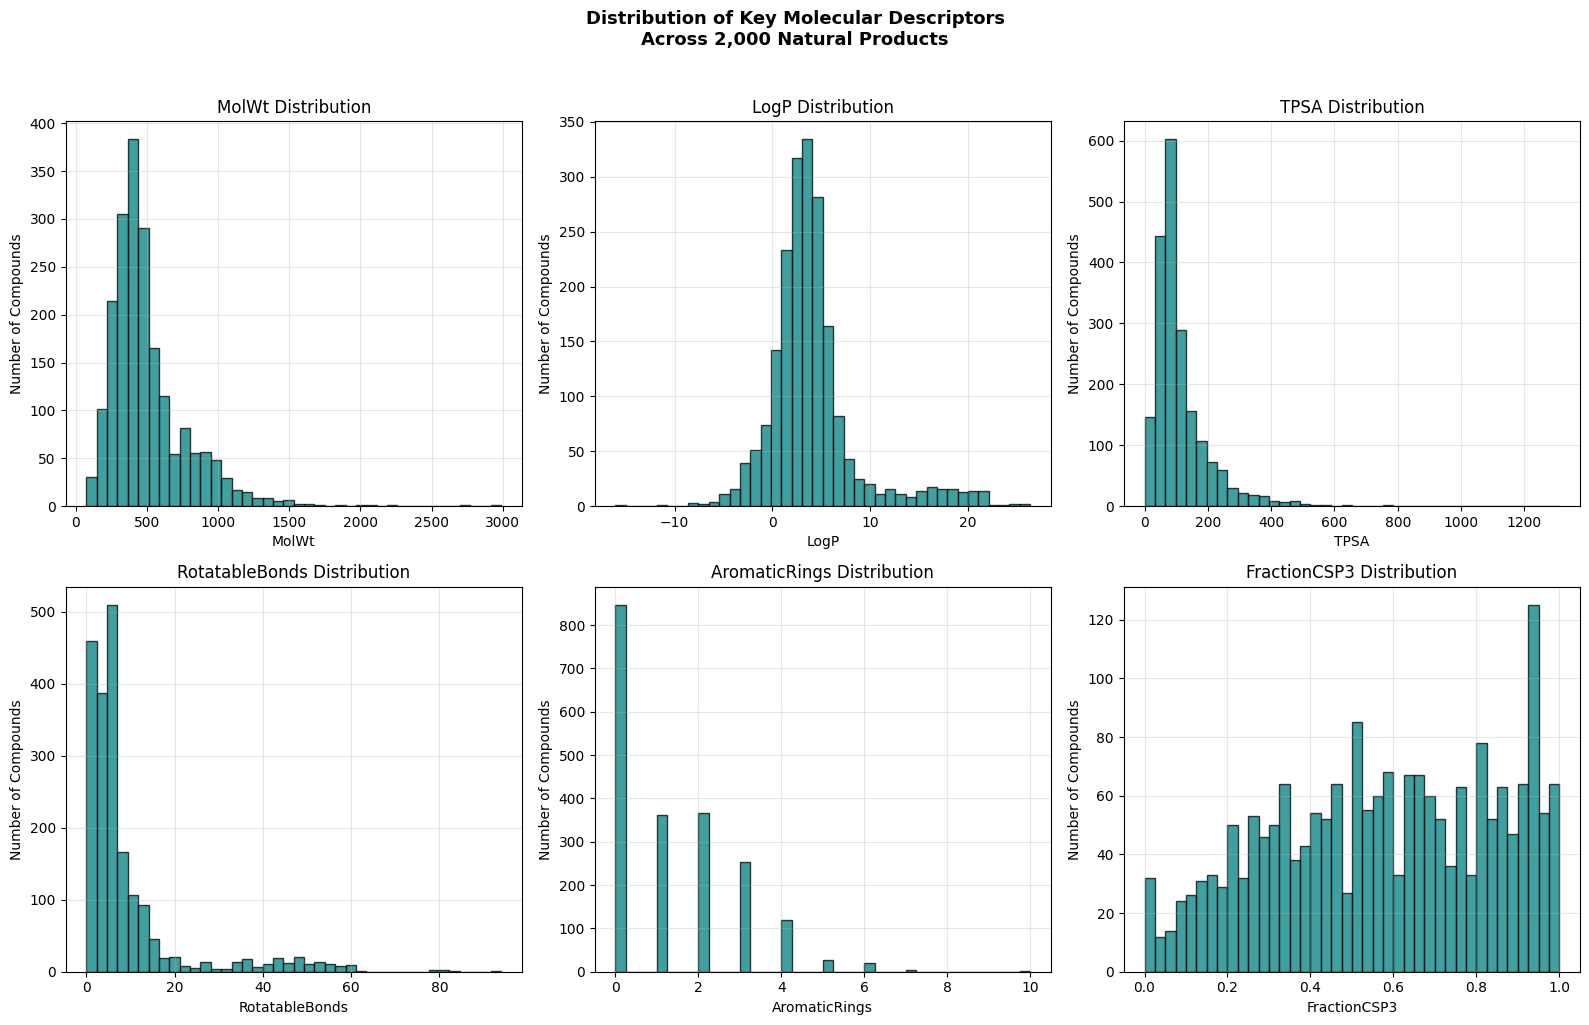


CORRELATION BETWEEN DESCRIPTORS
Highly correlated descriptors carry redundant information -
important to recognize before using them together in a
machine learning model (a concept directly relevant to the
QSAR practical that follows this one).


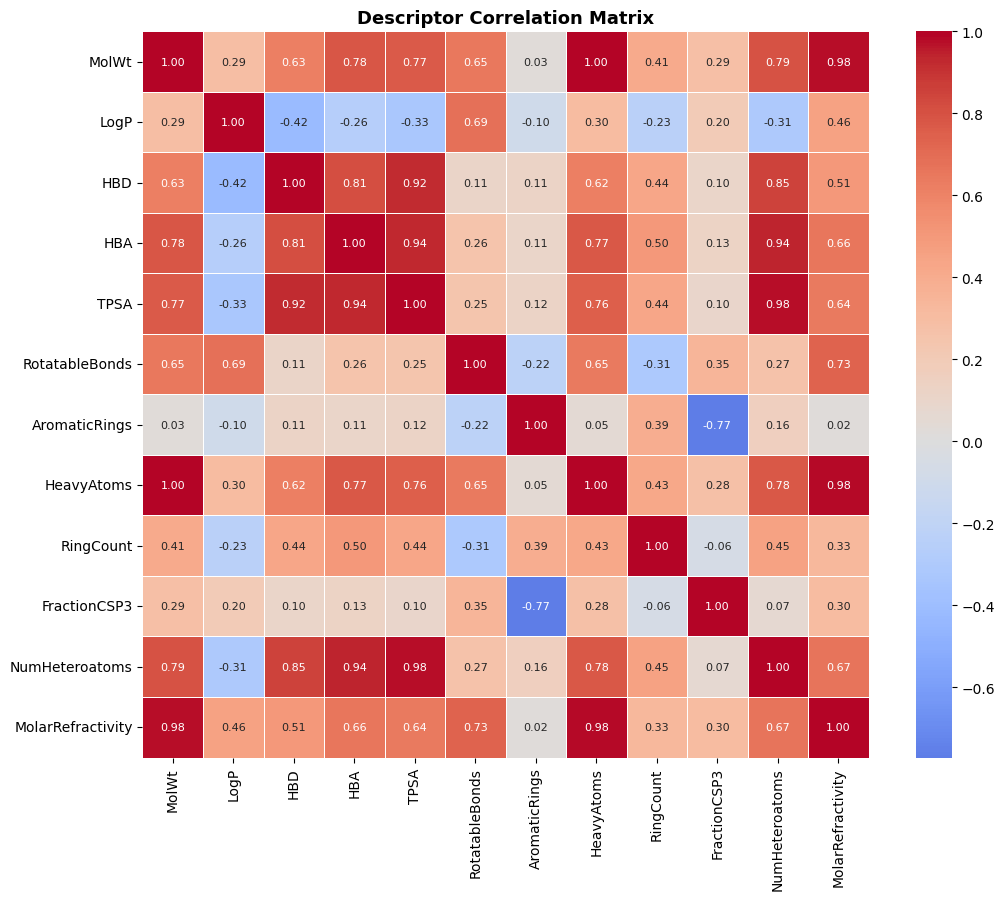


Descriptor pairs with strong correlation (|r| > 0.7):
  MolWt <-> HBA: r = 0.783
  MolWt <-> TPSA: r = 0.767
  MolWt <-> HeavyAtoms: r = 0.996
  MolWt <-> NumHeteroatoms: r = 0.793
  MolWt <-> MolarRefractivity: r = 0.978
  HBD <-> HBA: r = 0.814
  HBD <-> TPSA: r = 0.923
  HBD <-> NumHeteroatoms: r = 0.851
  HBA <-> TPSA: r = 0.936
  HBA <-> HeavyAtoms: r = 0.773
  HBA <-> NumHeteroatoms: r = 0.942
  TPSA <-> HeavyAtoms: r = 0.757
  TPSA <-> NumHeteroatoms: r = 0.975
  RotatableBonds <-> MolarRefractivity: r = 0.735
  AromaticRings <-> FractionCSP3: r = -0.771
  HeavyAtoms <-> NumHeteroatoms: r = 0.777
  HeavyAtoms <-> MolarRefractivity: r = 0.983

Why this matters: highly correlated descriptors provide
redundant information to a machine learning model without
adding new predictive value, and can sometimes cause
instability in linear models specifically.


In [3]:
# Block 3: Statistical analysis and correlation of molecular descriptors

print("="*60)
print("DESCRIPTOR CORRELATION ANALYSIS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_descriptors = ['MolWt', 'LogP', 'TPSA', 'RotatableBonds',
                      'AromaticRings', 'FractionCSP3']

for i, desc in enumerate(plot_descriptors):
    row_idx = i // 3
    col_idx = i % 3
    axes[row_idx, col_idx].hist(df[desc], bins=40, color='teal',
                                   edgecolor='black', alpha=0.75)
    axes[row_idx, col_idx].set_xlabel(desc)
    axes[row_idx, col_idx].set_ylabel('Number of Compounds')
    axes[row_idx, col_idx].set_title(f'{desc} Distribution')
    axes[row_idx, col_idx].grid(True, alpha=0.3)

plt.suptitle('Distribution of Key Molecular Descriptors\nAcross 2,000 Natural Products',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("CORRELATION BETWEEN DESCRIPTORS")
print(f"{'='*60}")
print("Highly correlated descriptors carry redundant information -")
print("important to recognize before using them together in a")
print("machine learning model (a concept directly relevant to the")
print("QSAR practical that follows this one).")
print("="*60)

corr_matrix = df[desc_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Descriptor Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_val)
            )

print(f"\nDescriptor pairs with strong correlation (|r| > 0.7):")
if high_corr_pairs:
    for d1, d2, corr_val in high_corr_pairs:
        print(f"  {d1} <-> {d2}: r = {corr_val:.3f}")
else:
    print("  None found")

print(f"\nWhy this matters: highly correlated descriptors provide")
print(f"redundant information to a machine learning model without")
print(f"adding new predictive value, and can sometimes cause")
print(f"instability in linear models specifically.")

Meaning of Block 3:

Purpose: Visualize how key descriptors are distributed across the natural product dataset, and quantitatively identify which descriptor pairs carry substantially overlapping information — a necessary consideration before any of these descriptors are used together in a predictive model.

What data comes IN: df from Blocks 1–2.

What happens inside — line by line:

The six-panel histogram grid shows the distribution shape of each key descriptor — revealing, for example, whether molecular weight is normally distributed or skewed, and how many compounds cluster at low versus high LogP.
corr_matrix = df[desc_cols].corr() — computes the Pearson correlation coefficient between every pair of the 12 physicochemical descriptors, producing a 12×12 correlation matrix.
The heatmap visualization uses a diverging color scale (coolwarm, centered at zero) — strong positive correlations appear deep red, strong negative correlations appear deep blue, and near-zero correlations appear near-white, making patterns immediately visible.
The high-correlation pair identification (threshold |r| > 0.7) is a standard, practical diagnostic step in real QSAR modelling — for example, MolWt and HeavyAtoms are almost always strongly correlated (both measure size in related ways), and recognizing this before model-building prevents unknowingly feeding redundant information into a predictive algorithm.

What comes OUT: A complete visual and statistical understanding of how the twelve descriptors relate to each other, directly informing feature selection decisions in the QSAR practical that follows.

VISUALIZING NATURAL PRODUCT CHEMICAL SPACE
Variance explained by PC1: 52.6%
Variance explained by PC2: 23.6%
Total variance captured in 2D: 76.1%


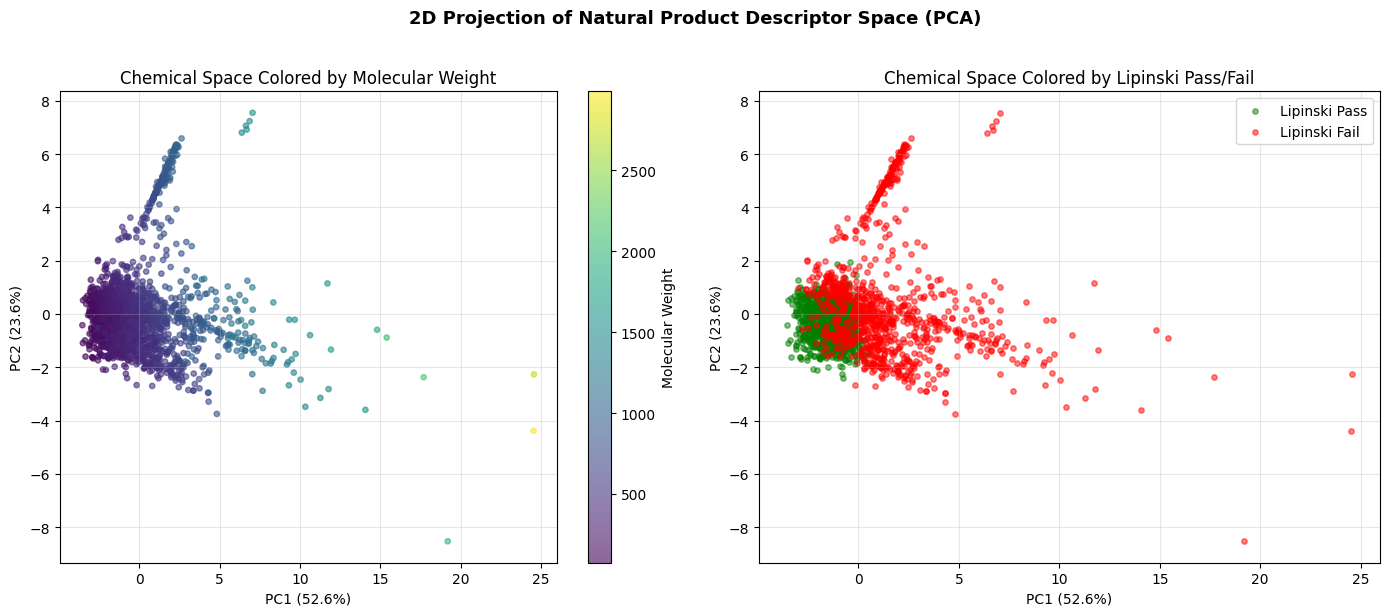


Top descriptors driving PC1:
MolWt             0.379082
HeavyAtoms        0.377132
NumHeteroatoms    0.367819
TPSA              0.366138
HBA               0.364037

Top descriptors driving PC2:
LogP              0.504778
RotatableBonds    0.460357
FractionCSP3      0.336764
AromaticRings     0.327436
RingCount         0.290768


In [4]:
# Block 4: PCA-based visualization of natural product chemical space

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("="*60)
print("VISUALIZING NATURAL PRODUCT CHEMICAL SPACE")
print("="*60)

X_desc = df[desc_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_desc)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

explained_var = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained_var[0]*100:.1f}%")
print(f"Variance explained by PC2: {explained_var[1]*100:.1f}%")
print(f"Total variance captured in 2D: {sum(explained_var)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(df['PC1'], df['PC2'], c=df['MolWt'],
                             cmap='viridis', s=15, alpha=0.6)
axes[0].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
axes[0].set_title('Chemical Space Colored by Molecular Weight')
plt.colorbar(scatter1, ax=axes[0], label='Molecular Weight')
axes[0].grid(True, alpha=0.3)

colors_map = {True: 'green', False: 'red'}
for status in [True, False]:
    mask = df['Lipinski_Pass'] == status
    axes[1].scatter(df.loc[mask, 'PC1'], df.loc[mask, 'PC2'],
                     c=colors_map[status], s=15, alpha=0.5,
                     label=f'Lipinski {"Pass" if status else "Fail"}')
axes[1].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
axes[1].set_title('Chemical Space Colored by Lipinski Pass/Fail')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('2D Projection of Natural Product Descriptor Space (PCA)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

pca_loadings = pd.DataFrame(
    pca.components_.T, columns=['PC1', 'PC2'], index=desc_cols
)
print(f"\nTop descriptors driving PC1:")
print(pca_loadings['PC1'].abs().sort_values(ascending=False).head(5).to_string())
print(f"\nTop descriptors driving PC2:")
print(pca_loadings['PC2'].abs().sort_values(ascending=False).head(5).to_string())

Meaning of Block 4:

Purpose: Compress the 12-dimensional descriptor space down to 2 dimensions for direct visualization, revealing the overall shape and structure of natural product chemical diversity, and showing precisely how molecular weight and drug-likeness status distribute across that space.

What data comes IN: df, desc_cols from Blocks 1–3.

What happens inside — line by line:

StandardScaler().fit_transform(X_desc) — standardizes all 12 descriptors to mean=0, standard deviation=1 before PCA, since descriptors like molecular weight (ranging into the hundreds) and FractionCSP3 (ranging 0 to 1) exist on vastly different scales.
PCA(n_components=2, random_state=42) — reduces the 12 standardized descriptors to their two most informative combined axes.
The left plot colors every compound by molecular weight, immediately revealing whether PC1 or PC2 primarily tracks molecular size.
The right plot colors compounds by Lipinski pass/fail status, directly visualizing whether drug-like and non-drug-like natural products occupy distinct regions of chemical space or overlap substantially — a genuinely informative result for understanding this dataset's overall character.
The PCA loadings reveal exactly which of the 12 original descriptors contribute most strongly to each principal component axis, connecting the abstract PC1/PC2 coordinates back to interpretable chemistry.

What comes OUT: df['PC1'], df['PC2'] — 2D coordinates for every compound. A complete visual map of the natural product dataset's chemical diversity.

MOLECULAR DESCRIPTOR CALCULATOR

********************************************************************
*                                                                  *
*   IMPORTANT - READ BEFORE RUNNING                                *
*                                                                  *
*   The value currently in the INPUT SECTION below is a           *
*   DEMONSTRATION VALUE ONLY.                                     *
*   It exists so this block runs successfully on first try.       *
*                                                                  *
*   TO CALCULATE DESCRIPTORS FOR YOUR OWN COMPOUND:                *
*   1. Scroll to "STUDENT INPUT SECTION" below                    *
*   2. REPLACE new_compound_name with your compound's name        *
*   3. REPLACE new_compound_smiles with your compound's SMILES    *
*      (get this from PubChem, ChemSpider, or your literature      *
*      reference - search the compound name + "SMILES")           *
*   4. D

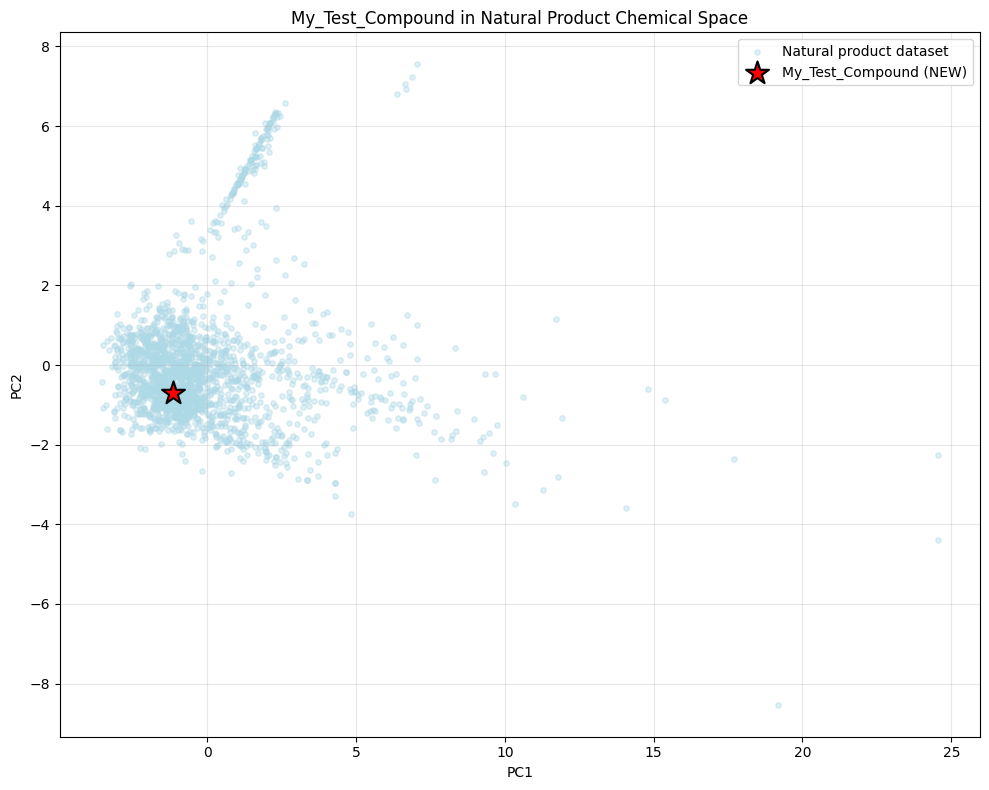


Interpretation: this plot shows where your compound sits
relative to the broader natural product chemical space -
a position near the main cluster suggests typical natural
product-like character; a position far from the cluster
suggests an atypical or unusually simple/complex structure.


In [5]:
# Block 5: DEPLOYMENT BLOCK
# Calculate the complete descriptor profile for any compound

print("="*70)
print("MOLECULAR DESCRIPTOR CALCULATOR")
print("="*70)
print("""
********************************************************************
*                                                                  *
*   IMPORTANT - READ BEFORE RUNNING                                *
*                                                                  *
*   The value currently in the INPUT SECTION below is a           *
*   DEMONSTRATION VALUE ONLY.                                     *
*   It exists so this block runs successfully on first try.       *
*                                                                  *
*   TO CALCULATE DESCRIPTORS FOR YOUR OWN COMPOUND:                *
*   1. Scroll to "STUDENT INPUT SECTION" below                    *
*   2. REPLACE new_compound_name with your compound's name        *
*   3. REPLACE new_compound_smiles with your compound's SMILES    *
*      (get this from PubChem, ChemSpider, or your literature      *
*      reference - search the compound name + "SMILES")           *
*   4. Do NOT change anything below                                *
*      "END OF INPUT SECTION"                                     *
*   5. Then run this cell again                                    *
*                                                                  *
*   No file upload is needed - all input is typed directly         *
*   into the Python variables below.                              *
*                                                                  *
*   REQUIREMENT: Blocks 1 through 4 must already have been run     *
*   successfully in this session, since this block compares your   *
*   compound against the full natural product dataset statistics.  *
*                                                                  *
********************************************************************
""")

# ============================================================
# STUDENT INPUT SECTION - EDIT EVERYTHING BELOW THIS LINE
# ============================================================

new_compound_name = "My_Test_Compound"          # <-- EDIT: type your compound's name

new_compound_smiles = "COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O"
# <-- EDIT: replace this entire line with YOUR compound's SMILES
# (demonstration value above is Curcumin - delete it and paste yours)

# ============================================================
# END OF INPUT SECTION - DO NOT EDIT ANYTHING BELOW THIS LINE
# ============================================================

print(f"\n{'='*70}")
print("CONFIRMING YOUR INPUT")
print(f"{'='*70}")
print(f"Compound name entered: {new_compound_name}")
print(f"SMILES entered: {new_compound_smiles}")
if new_compound_name == "My_Test_Compound":
    print("\n*** WARNING: You are still using the DEMONSTRATION value. ***")
    print("*** Edit the STUDENT INPUT SECTION above with your own data. ***")
print(f"{'='*70}")

mol_check = Chem.MolFromSmiles(new_compound_smiles)

if mol_check is None:
    print("\nERROR: Invalid SMILES. Check your SMILES string for typos.")
else:
    new_descriptors = calculate_descriptors(new_compound_smiles)

    print(f"\n{'='*70}")
    print(f"DESCRIPTOR PROFILE: {new_compound_name}")
    print(f"{'='*70}")
    for desc_name, value in new_descriptors.items():
        print(f"  {desc_name}: {value:.3f}" if isinstance(value, float)
              else f"  {desc_name}: {value}")

    lipinski_pass_new = (
        new_descriptors['MolWt'] <= 500 and
        new_descriptors['LogP'] <= 5 and
        new_descriptors['HBD'] <= 5 and
        new_descriptors['HBA'] <= 10
    )
    veber_pass_new = (
        new_descriptors['RotatableBonds'] <= 10 and
        new_descriptors['TPSA'] <= 140
    )

    print(f"\nDrug-likeness assessment:")
    print(f"  Lipinski Rule of Five: {'PASS' if lipinski_pass_new else 'FAIL'}")
    print(f"  Veber's Rules: {'PASS' if veber_pass_new else 'FAIL'}")

    print(f"\nComparison against the 2,000-compound natural product dataset:")
    for desc_name in ['MolWt', 'LogP', 'TPSA', 'AromaticRings']:
        dataset_mean = df[desc_name].mean()
        dataset_std = df[desc_name].std()
        compound_value = new_descriptors[desc_name]
        z_score = (compound_value - dataset_mean) / dataset_std
        print(f"  {desc_name}: {compound_value:.2f} "
              f"(dataset average: {dataset_mean:.2f}, "
              f"z-score: {z_score:+.2f})")

    new_scaled = scaler.transform([[new_descriptors[c] for c in desc_cols]])
    new_pca_coords = pca.transform(new_scaled)

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(df['PC1'], df['PC2'], c='lightblue',
                          s=15, alpha=0.4, label='Natural product dataset')
    ax.scatter(new_pca_coords[0, 0], new_pca_coords[0, 1],
               color='red', s=300, marker='*',
               edgecolor='black', linewidth=1.5,
               label=f'{new_compound_name} (NEW)', zorder=5)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'{new_compound_name} in Natural Product Chemical Space')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nInterpretation: this plot shows where your compound sits")
    print(f"relative to the broader natural product chemical space -")
    print(f"a position near the main cluster suggests typical natural")
    print(f"product-like character; a position far from the cluster")
    print(f"suggests an atypical or unusually simple/complex structure.")

Meaning of Block 5:

Purpose: A complete, self-contained descriptor calculation tool where a student inputs any compound's SMILES and receives its full 12-descriptor physicochemical profile, drug-likeness assessment, statistical comparison against the natural product dataset, and a visual position within that dataset's chemical space.

What data comes IN: Student-typed compound name and SMILES. calculate_descriptors, desc_cols, df, scaler, pca from all previous blocks.

What happens inside — line by line:

The warning banner and confirmation echo follow the identical safeguard pattern established throughout your entire series.
calculate_descriptors(new_compound_smiles) — reuses the exact same function from Block 1, guaranteeing the new compound is characterized identically to every compound in the reference dataset.
The z-score comparison (z_score = (compound_value - dataset_mean) / dataset_std) tells a student, in standard-deviation units, how typical or atypical their compound's specific descriptor values are relative to the broader natural product population — a z-score near 0 means typical, a z-score beyond ±2 means notably unusual.
scaler.transform(...) and pca.transform(...) — critically use .transform(), never .fit_transform(), applying the exact scaling and rotation parameters learned from the 2,000-compound dataset in Block 4, ensuring the new compound is placed on a directly comparable footing.
The final scatter plot visually situates the new compound within the established natural product chemical space, giving an intuitive sense of how structurally typical or unusual it is compared to real, verified natural products.

What comes OUT: A complete descriptor profile, drug-likeness verdict, statistical context, and visual chemical-space position for any compound a student chooses to characterize.